In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv


## DATA OVERVIEW

In [2]:
df=pd.read_csv('/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv')
df

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,41.40,Healthcare,Mastercard,OTP,POS,Android Phone,False,8.82,2,...,False,False,0,17.3,2,3,False,29.6,1,0
19996,19997,47.92,Online Retail,Visa,OTP,POS,Android Phone,False,45.81,1,...,False,False,0,9.0,4,0,False,29.2,1,0
19997,19998,10.25,Restaurants,Visa,3D Secure,In-App,Tablet,False,20.67,0,...,False,False,1,1.0,19,5,False,22.9,0,0
19998,19999,31.34,Travel,Visa,3D Secure,Online,Android Phone,False,22.94,2,...,False,False,0,8.8,2,1,False,27.9,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [4]:
df.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

**No duplicate entries.**

In [6]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

**No null entries in the dataset either.**

In [7]:
df.shape

(20000, 26)

**The dataset contains 20000 entries and 26 columns.**

In [8]:
df['is_fraud'].value_counts()

is_fraud
0    19661
1      339
Name: count, dtype: int64

**0 signifies not fraud, 1 signifies is fraud. The percentage of actually fraud entries in the dataset is around 1.7% of the entire dataset, this shows that the dataset is heavily imbalanced in the first placed and contains almost 98.3% of 'not fraud' entries.**

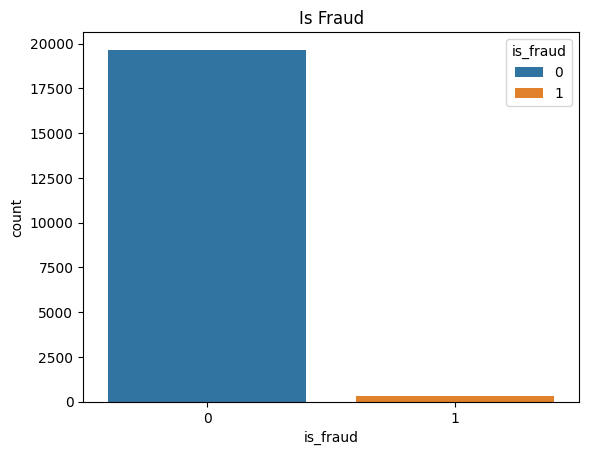

In [9]:
sns.countplot(data=df,x='is_fraud',hue='is_fraud')
plt.title('Is Fraud')
plt.show()

**A countplot showing the severe imbalance between the two classes of our target cateogorical variable.**

In [10]:
df.drop(columns='transaction_id',inplace=True)

**Dropping Transaction ID as it is unique for every entry, and hence offers no help in fraud detection.**

In [11]:
num_cols=df.select_dtypes(include=['float64', 'int64']).columns
cat_cols=df.select_dtypes(include=['object','bool']).columns

print(num_cols)
print(cat_cols)

Index(['amount_usd', 'hours_since_last_txn', 'txn_count_last_24h',
       'distance_from_home_km', 'card_age_months', 'customer_age',
       'account_balance_usd', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'merchant_risk_score',
       'prior_disputes', 'is_fraud'],
      dtype='object')
Index(['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type', 'is_foreign_transaction', 'is_new_merchant', 'used_vpn',
       'ip_country_mismatch', 'billing_shipping_mismatch',
       'is_ai_generated_scam_attempt'],
      dtype='object')


**The categorical and numerical columns in the dataset.**

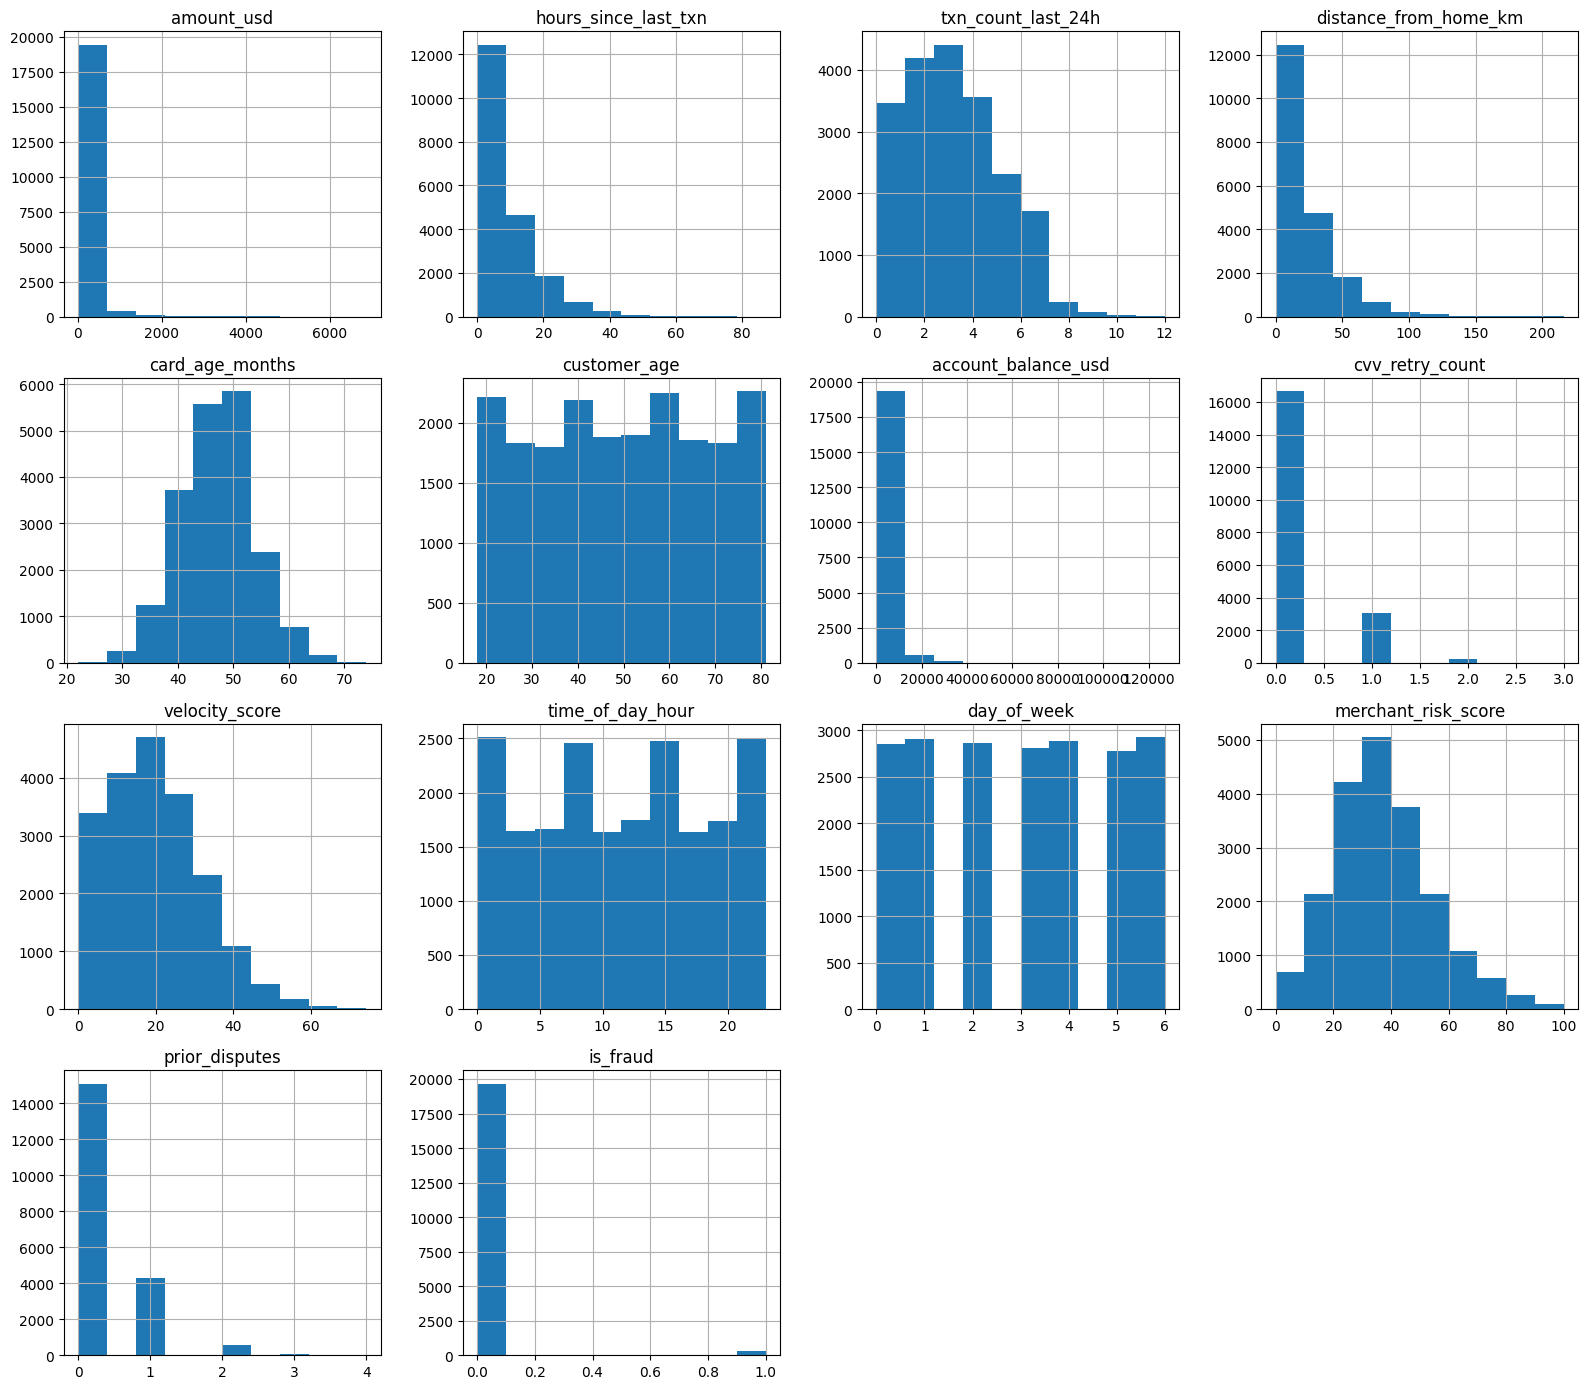

In [12]:
df[num_cols].hist(figsize=(16,14))
plt.tight_layout()

In [13]:
df.skew(numeric_only=True)

amount_usd                      7.210563
is_foreign_transaction          3.632783
hours_since_last_txn            1.887158
txn_count_last_24h              0.552901
distance_from_home_km           2.026137
card_age_months                 0.118252
customer_age                   -0.014378
account_balance_usd             5.629769
is_new_merchant                 1.282932
used_vpn                        2.909948
ip_country_mismatch             3.770504
billing_shipping_mismatch       4.467454
cvv_retry_count                 2.291405
velocity_score                  0.540735
time_of_day_hour               -0.010263
day_of_week                     0.007560
is_ai_generated_scam_attempt    7.096478
merchant_risk_score             0.572794
prior_disputes                  1.876057
is_fraud                        7.484831
dtype: float64


**The skewness analysis shows that several features are positively skewed, particularly **amount_usd, account_balance_usd, is_ai_generated_scam_attempt, and is_fraud**, which have skewness values above 5. Other features such as **is_foreign_transaction, used_vpn, ip_country_mismatch, billing_shipping_mismatch, cvv_retry_count, hours_since_last_txn, distance_from_home_km, and prior_disputes** also show noticeable positive skewness.Features such as **card_age_months, customer_age, time_of_day_hour, and day_of_week** have skewness values close to zero, indicating that their distributions are relatively symmetric. Overall, the dataset contains several highly right-skewed features, which is expected in a fraud-detection dataset where certain events occur rarely.**


In [14]:
df.kurt(numeric_only=True)

amount_usd                      87.553827
is_foreign_transaction          11.198230
hours_since_last_txn             5.050429
txn_count_last_24h               0.243040
distance_from_home_km            6.242478
card_age_months                 -0.011064
customer_age                    -1.192991
account_balance_usd             70.300806
is_new_merchant                 -0.354122
used_vpn                         6.468445
ip_country_mismatch             12.217922
billing_shipping_mismatch       17.959939
cvv_retry_count                  5.058323
velocity_score                   0.171848
time_of_day_hour                -1.206336
day_of_week                     -1.254670
is_ai_generated_scam_attempt    48.364832
merchant_risk_score              0.436392
prior_disputes                   3.476174
is_fraud                        54.028098
dtype: float64


**The kurtosis analysis shows that several features have very high positive kurtosis, indicating the presence of **heavy tails and potential outliers** in their distributions. The most notable features are **amount_usd (87.55), account_balance_usd (70.30), is_ai_generated_scam_attempt (48.36), and is_fraud (54.03)**.Other features such as **billing_shipping_mismatch (17.96), ip_country_mismatch (12.22), is_foreign_transaction (11.20), used_vpn (6.47), distance_from_home_km (6.24), cvv_retry_count (5.06), hours_since_last_txn (5.05), and prior_disputes (3.48)** also show relatively high kurtosis, suggesting heavier-than-normal tails.In contrast, **card_age_months (-0.01), txn_count_last_24h (0.24), velocity_score (0.17), and merchant_risk_score (0.44)** have kurtosis values closer to zero, indicating distributions with relatively lighter tails and fewer extreme observations compared to the highly kurtotic features.Overall, the dataset contains several features with **heavy-tailed distributions and potential outliers**, particularly among transaction amounts, account balances, and several binary fraud-related indicators.**


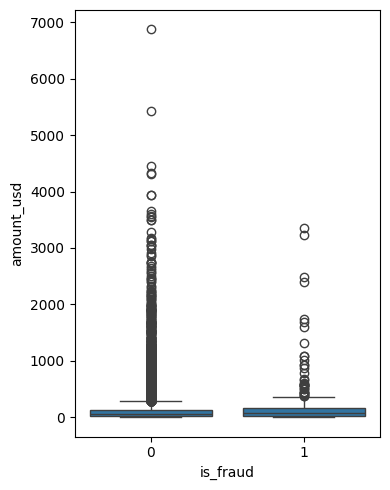

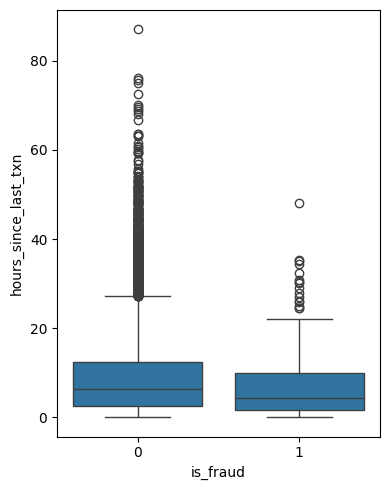

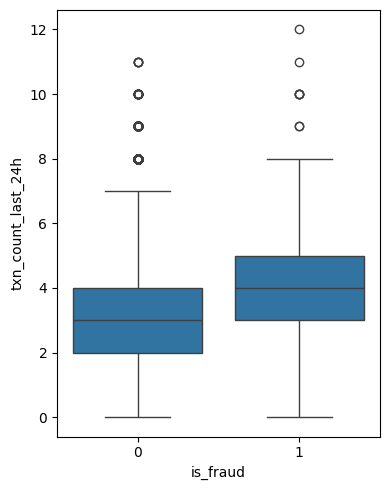

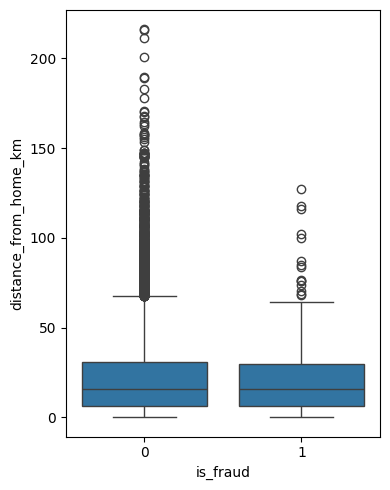

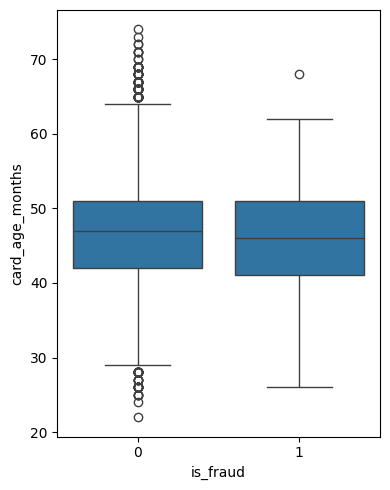

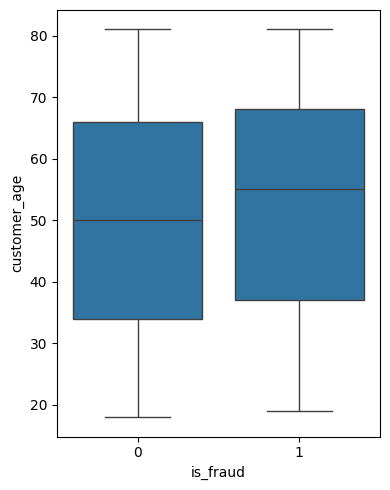

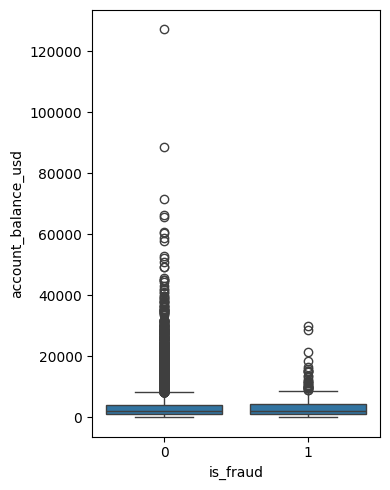

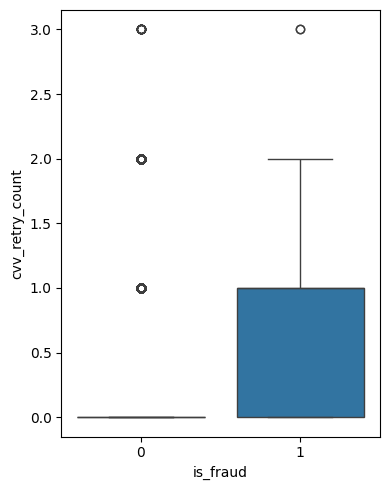

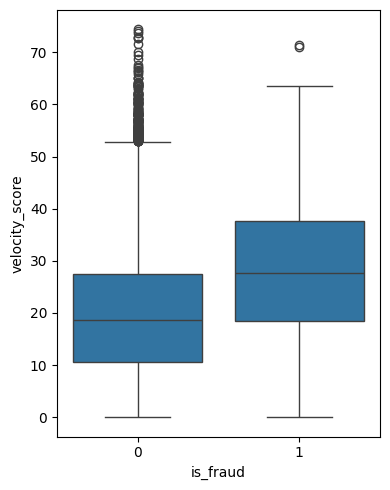

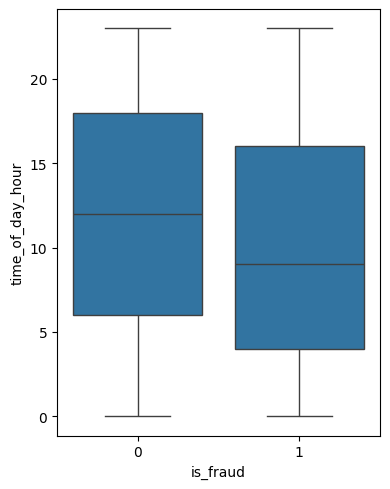

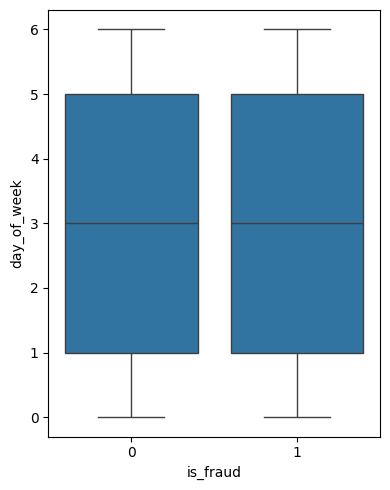

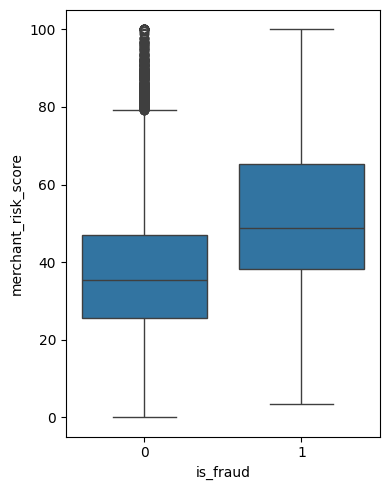

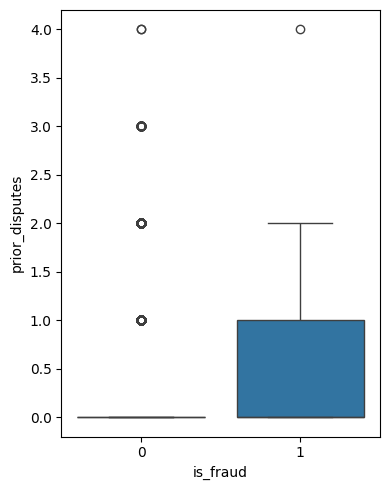

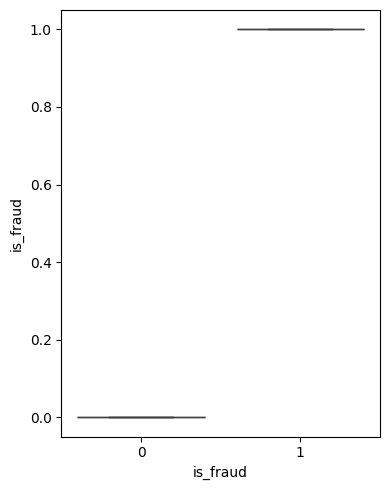

In [15]:
for col in num_cols: 
    plt.figure(figsize=(4,5)) 
    sns.boxplot(data=df, x='is_fraud',y=col) 
    plt.tight_layout()

In [16]:
from scipy.stats import ttest_ind

features = ['amount_usd', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'merchant_risk_score', 'prior_disputes']

for feature in features:
    group0 = df[df['is_fraud'] == 0][feature]
    group1 = df[df['is_fraud'] == 1][feature]

    t_stat, p_value = ttest_ind(group0, group1)

    print(f"\n{feature}")
    print(f"t-statistic: {t_stat}")
    print(f"p-value: {p_value}")


amount_usd
t-statistic: -3.529467735314939
p-value: 0.00041733152273327567

hours_since_last_txn
t-statistic: 4.074203305191449
p-value: 4.6350197046062445e-05

txn_count_last_24h
t-statistic: -8.48112322465184
p-value: 2.3832045697237733e-17

distance_from_home_km
t-statistic: 0.606960514611307
p-value: 0.5438840072747498

card_age_months
t-statistic: 1.7063455155481824
p-value: 0.08795929466395899

customer_age
t-statistic: -2.764194848617295
p-value: 0.0057115684667362705

account_balance_usd
t-statistic: -0.6181921803185386
p-value: 0.5364557042752007

cvv_retry_count
t-statistic: -22.262003487613025
p-value: 1.791480251310221e-108

velocity_score
t-statistic: -13.818785498253623
p-value: 3.103319925748701e-43

time_of_day_hour
t-statistic: 4.359588950880492
p-value: 1.309574206652517e-05

day_of_week
t-statistic: -0.8585441047116099
p-value: 0.39060237749798166

merchant_risk_score
t-statistic: -15.316515982831179
p-value: 1.1807455129718283e-52

prior_disputes
t-statistic: -3.38

The t-test results show that **amount_usd, hours_since_last_txn, txn_count_last_24h, customer_age, cvv_retry_count, velocity_score, time_of_day_hour, merchant_risk_score, and prior_disputes** have statistically significant differences between fraudulent and non-fraudulent transactions, as their p-values are below 0.05. Among these, **cvv_retry_count, velocity_score, and merchant_risk_score** show particularly strong statistical significance due to their extremely small p-values.

On the other hand, **distance_from_home_km, card_age_months, account_balance_usd, and day_of_week** have p-values greater than 0.05, indicating that there is no statistically significant difference between fraudulent and non-fraudulent transactions for these features.

In [17]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    table = pd.crosstab(df[col], df['is_fraud'])
    chi2, p, dof, expected = chi2_contingency(table)
    
    print(f"{col}: Chi2 = {chi2:.4f}") 
    print(f"P-value = {p:.4e}")

merchant_category: Chi2 = 120.6465
P-value = 1.3438e-20
card_type: Chi2 = 4.4615
P-value = 3.4714e-01
auth_method: Chi2 = 132.2100
P-value = 1.3114e-27
channel: Chi2 = 6.2059
P-value = 1.8429e-01
device_type: Chi2 = 7.3285
P-value = 3.9549e-01
is_foreign_transaction: Chi2 = 136.7543
P-value = 1.3647e-31
is_new_merchant: Chi2 = 115.3414
P-value = 6.6251e-27
used_vpn: Chi2 = 81.5312
P-value = 1.7251e-19
ip_country_mismatch: Chi2 = 273.4817
P-value = 1.9775e-61
billing_shipping_mismatch: Chi2 = 199.6588
P-value = 2.4791e-45
is_ai_generated_scam_attempt: Chi2 = 120.1665
P-value = 5.8168e-28


The Chi-square test results show that **merchant_category, auth_method, is_foreign_transaction, is_new_merchant, used_vpn, ip_country_mismatch, billing_shipping_mismatch, and is_ai_generated_scam_attempt** have statistically significant associations with fraud, as their p-values are below 0.05. Among these, **ip_country_mismatch, billing_shipping_mismatch, and is_foreign_transaction** show particularly strong statistical significance due to their extremely small p-values.

On the other hand, **card_type, channel, and device_type** have p-values greater than 0.05, indicating that there is no statistically significant association between these categorical variables and fraud.

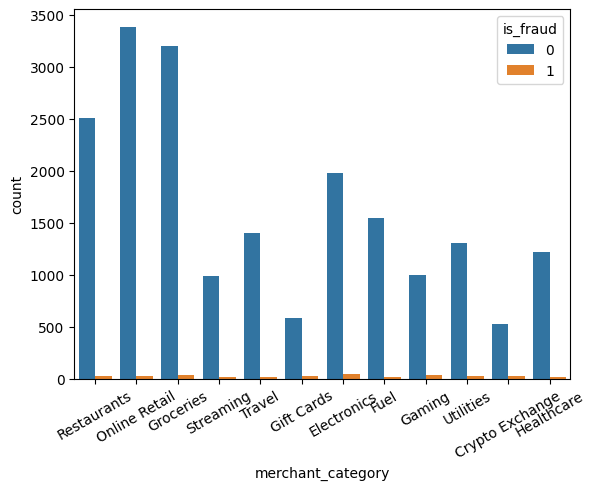

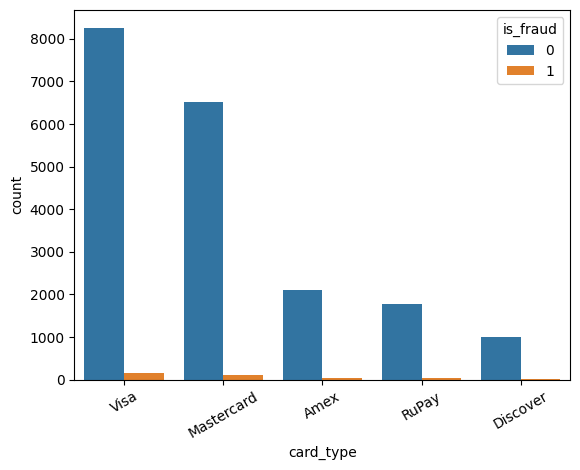

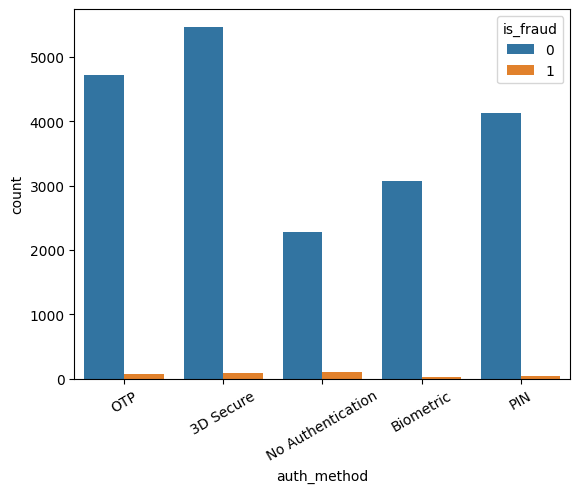

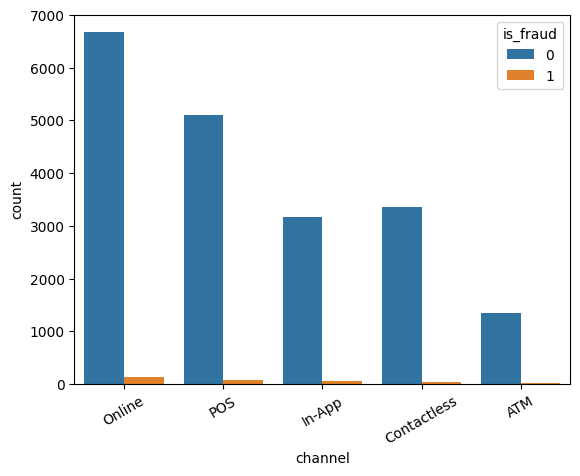

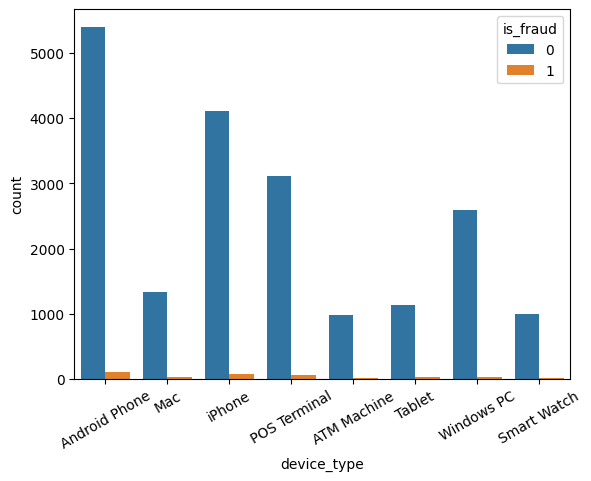

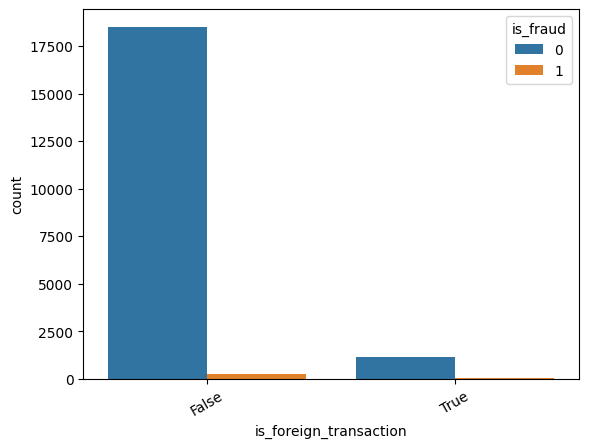

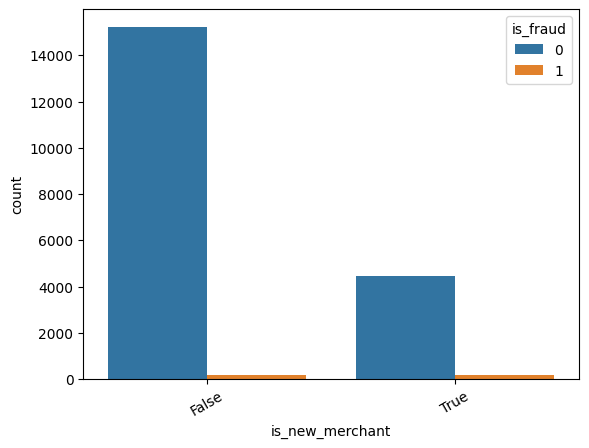

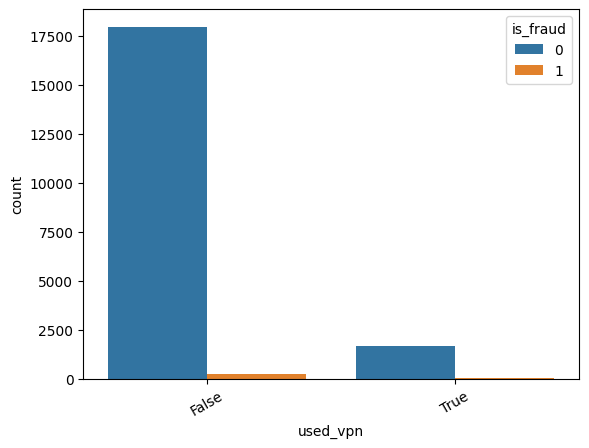

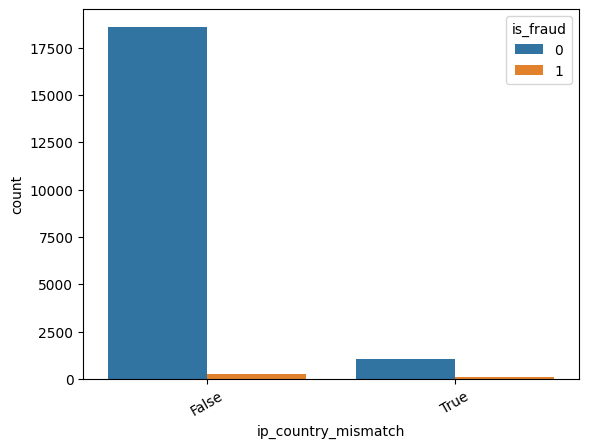

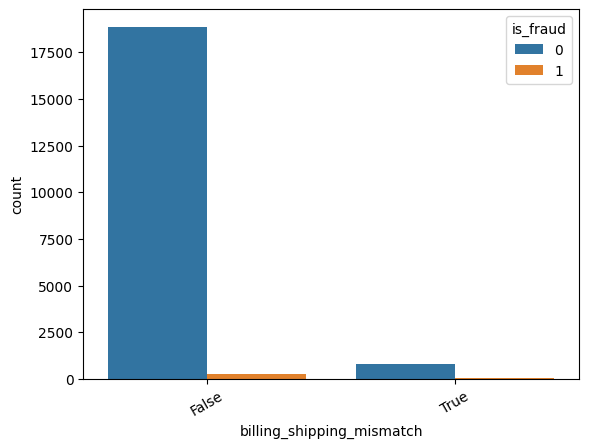

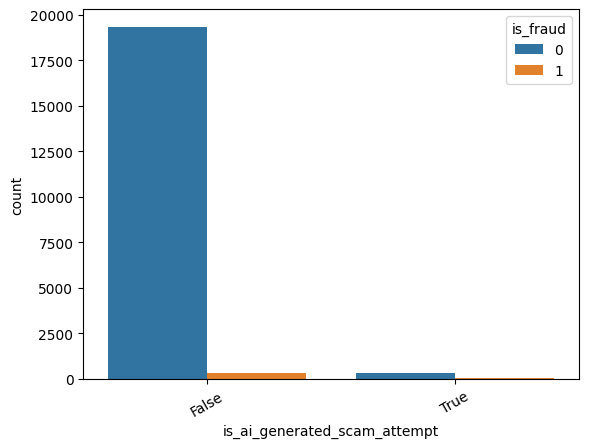

In [18]:
for col in cat_cols:
    sns.countplot(data=df,x=col,hue="is_fraud")
    plt.xticks(rotation=30)
    plt.show()

In [19]:
corr=df.corr(numeric_only=True)
corr['is_fraud'].sort_values(ascending=False)

is_fraud                        1.000000
cvv_retry_count                 0.155509
ip_country_mismatch             0.117763
merchant_risk_score             0.107680
billing_shipping_mismatch       0.100863
velocity_score                  0.097255
is_foreign_transaction          0.083494
is_ai_generated_scam_attempt    0.078941
is_new_merchant                 0.076401
used_vpn                        0.064532
txn_count_last_24h              0.059866
amount_usd                      0.024951
prior_disputes                  0.023903
customer_age                    0.019543
day_of_week                     0.006071
account_balance_usd             0.004371
distance_from_home_km          -0.004292
card_age_months                -0.012065
hours_since_last_txn           -0.028798
time_of_day_hour               -0.030814
Name: is_fraud, dtype: float64

<Axes: >

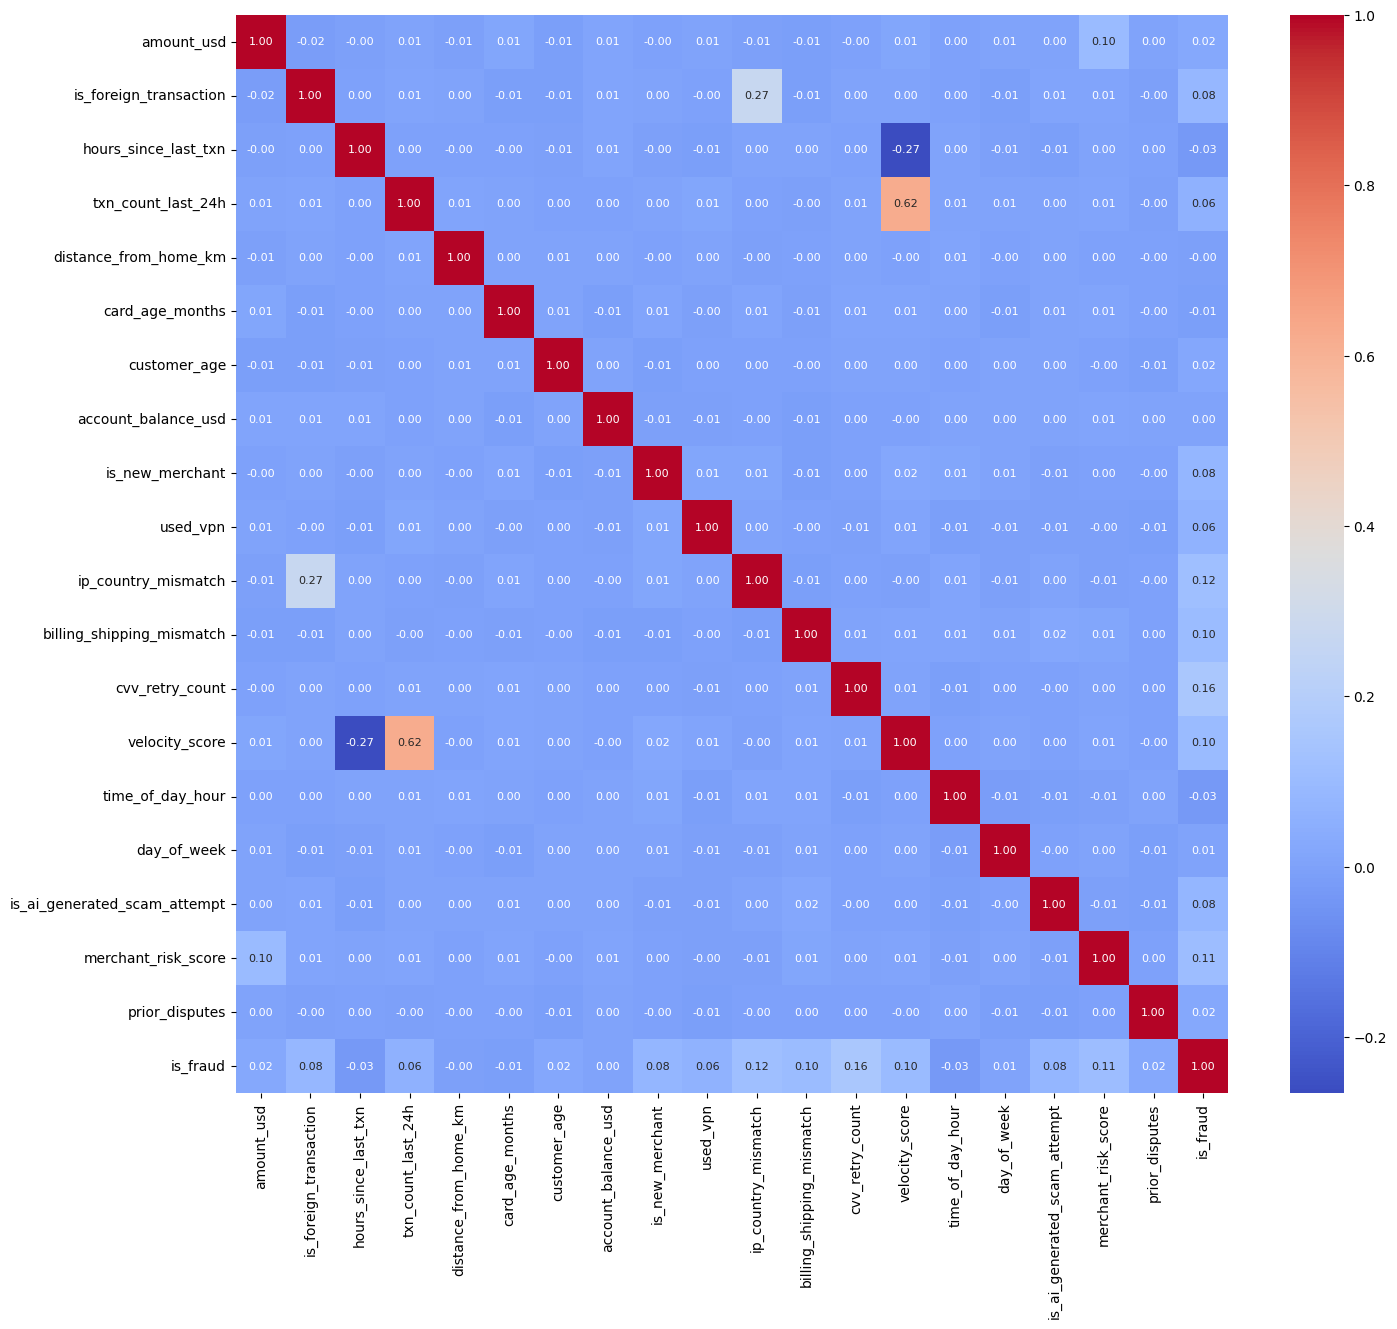

In [20]:
plt.figure(figsize=(16,14))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size":8})

**None of the features are highly correlated with each other, hence no multi-collinearity. We do not give remove or get rid of any of these columns, then.**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   amount_usd                    20000 non-null  float64
 1   merchant_category             20000 non-null  object 
 2   card_type                     20000 non-null  object 
 3   auth_method                   20000 non-null  object 
 4   channel                       20000 non-null  object 
 5   device_type                   20000 non-null  object 
 6   is_foreign_transaction        20000 non-null  bool   
 7   hours_since_last_txn          20000 non-null  float64
 8   txn_count_last_24h            20000 non-null  int64  
 9   distance_from_home_km         20000 non-null  float64
 10  card_age_months               20000 non-null  int64  
 11  customer_age                  20000 non-null  int64  
 12  account_balance_usd           20000 non-null  float64
 13  i

In [22]:
df=pd.get_dummies(df,columns=['merchant_category','card_type','auth_method','channel','device_type'])

**One hot encoding these columns as they contain more than one category/class, this prevents the model from interpreting the encoding as a hierarchy of some kind.**

In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
label_cols=['is_foreign_transaction','is_new_merchant','used_vpn','ip_country_mismatch','billing_shipping_mismatch',
            'is_ai_generated_scam_attempt']
for col in label_cols:
    df[col]=le.fit_transform(df[col])

**These columns contain only two categories, so there's less risk of the model interpreting any sort of hierarchy.**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 55 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   amount_usd                         20000 non-null  float64
 1   is_foreign_transaction             20000 non-null  int64  
 2   hours_since_last_txn               20000 non-null  float64
 3   txn_count_last_24h                 20000 non-null  int64  
 4   distance_from_home_km              20000 non-null  float64
 5   card_age_months                    20000 non-null  int64  
 6   customer_age                       20000 non-null  int64  
 7   account_balance_usd                20000 non-null  float64
 8   is_new_merchant                    20000 non-null  int64  
 9   used_vpn                           20000 non-null  int64  
 10  ip_country_mismatch                20000 non-null  int64  
 11  billing_shipping_mismatch          20000 non-null  int

## MODEL

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df.drop(columns='is_fraud')

y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    y_pred = (y_prob >= threshold).astype(int)

    print("Threshold:", threshold)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("--------------------------------")

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

Threshold: 0.1
[[3822  110]
 [  22   46]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3932
           1       0.29      0.68      0.41        68

    accuracy                           0.97      4000
   macro avg       0.64      0.82      0.70      4000
weighted avg       0.98      0.97      0.97      4000

--------------------------------
Threshold: 0.2
[[3889   43]
 [  34   34]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.44      0.50      0.47        68

    accuracy                           0.98      4000
   macro avg       0.72      0.74      0.73      4000
weighted avg       0.98      0.98      0.98      4000

--------------------------------
Threshold: 0.3
[[3915   17]
 [  41   27]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3932
           1       0.61      0.40      0.48  

**We are first trying Logistic Regression here with different thresholds to find the best F1 score. Since our dataset is heavily imabalanced, the F1 score is our best measure for how good a model is. We cannot rely on accuracy, precision or recall by themselves. Our Logistic Regression Model gives us a decent F1-score of 0.48 at a threshold of 0.3.**

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.drop(columns='is_fraud')
y = df['is_fraud']


X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=60,stratify=y)


scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

regressor = DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_leaf=5,random_state=60)

regressor.fit(X_train_scaled, y_train)

y_pred = regressor.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3908   24]
 [  65    3]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3932
           1       0.11      0.04      0.06        68

    accuracy                           0.98      4000
   macro avg       0.55      0.52      0.53      4000
weighted avg       0.97      0.98      0.97      4000



**Now we first try a basic decision tree model without any changed or hyper-parameter tuning. As we can see the metrics for Class 1 are abyssmal across the board, may it be precision, recall or f1 score. And since we are focusing on f1 score due to our imbalanced dataset.**

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.drop(columns='is_fraud')
y = df['is_fraud']


X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=60,stratify=y)


scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Features before PCA:", X_train.shape[1])
print("Features after PCA:", X_train_pca.shape[1])
print("Variance retained:", sum(pca.explained_variance_ratio_))
print("Variance retained:", pca.explained_variance_ratio_.sum())


regressor = DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_leaf=3,class_weight='balanced',
                                           random_state=60)

regressor.fit(X_train_pca, y_train)

y_pred = regressor.predict(X_test_pca)

train_accuracy = regressor.score(X_train_pca, y_train)
test_accuracy = regressor.score(X_test_pca, y_test)

print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))

Features before PCA: 54
Features after PCA: 32
Variance retained: 0.9504292479377077
Variance retained: 0.9504292479377079
Training Accuracy: 0.7858125
Test Accuracy: 0.78975
Confusion Matrix
[[3117  815]
 [  26   42]]
Classification Report
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      3932
           1       0.05      0.62      0.09        68

    accuracy                           0.79      4000
   macro avg       0.52      0.71      0.49      4000
weighted avg       0.98      0.79      0.87      4000



**PCA is used for dimensionality reduction, after all our one hot encoding and label encoding, our number of columns blew up from 26 to about 54 overall, this is a decently large number of columns for us to build models on, so we try conducting a principal component analysis to reduce those number of columns. We were able to reduce the number of columns from 54 to 32 while still retaining variance of 95.042%, but the model did not improve by that much overall.**

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.drop(columns='is_fraud')
y = df['is_fraud']


X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=60,stratify=y)


scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for depth in [3, 4, 5, 6, 7, 8, 10, None]:
    for leaf in [1, 2, 5, 10]:

        regressor = DecisionTreeClassifier(criterion='gini',max_depth=depth,min_samples_leaf=leaf,class_weight='balanced',
            random_state=60)

        regressor.fit(X_train_scaled, y_train)

        y_pred = regressor.predict(X_test_scaled)

        print(f"Max Depth: {depth}, Min Samples Leaf: {leaf}")
        print(classification_report(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))
        print("--------------------------------------------------")

Max Depth: 3, Min Samples Leaf: 1
              precision    recall  f1-score   support

           0       0.99      0.71      0.83      3932
           1       0.04      0.75      0.08        68

    accuracy                           0.71      4000
   macro avg       0.52      0.73      0.45      4000
weighted avg       0.98      0.71      0.81      4000

[[2775 1157]
 [  17   51]]
--------------------------------------------------
Max Depth: 3, Min Samples Leaf: 2
              precision    recall  f1-score   support

           0       0.99      0.71      0.83      3932
           1       0.04      0.75      0.08        68

    accuracy                           0.71      4000
   macro avg       0.52      0.73      0.45      4000
weighted avg       0.98      0.71      0.81      4000

[[2775 1157]
 [  17   51]]
--------------------------------------------------
Max Depth: 3, Min Samples Leaf: 5
              precision    recall  f1-score   support

           0       0.99      0.71

**Manually trying out different hyper-parameter by running two nested 'for-loops'. But we obviously have much better methods than that for hyper-parameter tuning like gridsearch, bayesian optimization etc.**

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=60)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print(y_train_smote.value_counts())
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

regressor = DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_leaf=5,random_state=60)

regressor.fit(X_train_smote, y_train_smote)

y_pred = regressor.predict(X_test)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))

Before SMOTE:
is_fraud
0    15729
1      271
Name: count, dtype: int64
After SMOTE:
is_fraud
0    15729
1    15729
Name: count, dtype: int64
Confusion Matrix
[[3478  454]
 [  43   25]]
Classification Report
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      3932
           1       0.05      0.37      0.09        68

    accuracy                           0.88      4000
   macro avg       0.52      0.63      0.51      4000
weighted avg       0.97      0.88      0.92      4000



**SMOTE is basically a technique for dealing with imbalanced classes.Our dataset has:Normal transactions: 19,661,Fraud transactions: 339. So the model sees far more examples of class 0 than class 1. So what SMOTE does is, instead of simply copying the 339 fraud transactions, it creates new synthetic fraud examples based on existing fraud examples. So we basically made the training data 50/50 balanced. SMOTE gives the model many more examples of the minority class so it has a better opportunity to learn patterns associated with fraud.**

**But once again, despite using SMOTE, our f1 score does not increase by much.**

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {'criterion': ['gini', 'entropy'],'max_depth': [3, 5, 7, 10, None],'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10, 20],}

grid = GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced',random_state=60),
    param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
0.1396677511028681
[[3823  109]
 [  59    9]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3932
           1       0.08      0.13      0.10        68

    accuracy                           0.96      4000
   macro avg       0.53      0.55      0.54      4000
weighted avg       0.97      0.96      0.96      4000



**We perform the grid search hyper-parameter tuning technique, focusing on the f1 score, but even with our grid search focusing on the f1 score, there is still not a great increase in the model scores.**

In [31]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

def objective(trial):

    model = DecisionTreeClassifier(criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20), min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        class_weight="balanced",random_state=60)

    score = cross_val_score(model,X_train,y_train,cv=5,scoring="f1").mean()

    return score


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=50)

print("Best Parameters:")
print(study.best_params)

print("Best CV F1:")
print(study.best_value)


best_model = DecisionTreeClassifier(**study.best_params,class_weight="balanced",random_state=60)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

[I 2026-08-17 02:59:21,576] A new study created in memory with name: no-name-c270bc50-7368-482e-bdcd-cbc51b6c1a54
[I 2026-08-17 02:59:22,320] Trial 0 finished with value: 0.10030977180115874 and parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 12, 'min_samples_split': 7}. Best is trial 0 with value: 0.10030977180115874.
[I 2026-08-17 02:59:23,159] Trial 1 finished with value: 0.10801914602030963 and parameters: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 3, 'min_samples_split': 17}. Best is trial 1 with value: 0.10801914602030963.
[I 2026-08-17 02:59:23,987] Trial 2 finished with value: 0.11563718110029278 and parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2}. Best is trial 2 with value: 0.11563718110029278.
[I 2026-08-17 02:59:24,741] Trial 3 finished with value: 0.10836105967264628 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 4}. Best is tria

Best Parameters:
{'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 15, 'min_samples_split': 15}
Best CV F1:
0.12816915474181276
Confusion Matrix:
[[3528  404]
 [  45   23]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      3932
           1       0.05      0.34      0.09        68

    accuracy                           0.89      4000
   macro avg       0.52      0.62      0.52      4000
weighted avg       0.97      0.89      0.93      4000



**We finally try bayesian optimization, another hyper-parameter tuning technique, bayesian optimization basically learns from it's preceding hyper-parameters, to see which of them give the best results for the score we're focusing on. Our f1 score improves by a bit, but it's still not close to any range that can be called 'good'.**

## CONCLUSION

**One conclusion that can be made here is that perhaps after all this experimentation, the decision tree ML model is not a good fit for this dataset, Logistic Regression gives us a much better f1 score, precision and recall overall. Logistic Regression gives us a F1 score of 0.48, which is the highest observed after all our trials and experimentations.**